In [1]:
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [2]:
results_folder = "../results/TimeSeries/3D"
create_folder(results_folder)

In [2]:
#process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [45]:
import os, glob, re, json
from pathlib import Path
import numpy as np

L   = 128
DIM = 3
NT  = 3000
K   = 1.0e-06

NC_list  = [2, 4, 8]
RHO_list = [round(1/nc, 2) for nc in NC_list]
compute_means_for_folder(L, DIM, NT, K, NC_list, RHO_list)

[OK] Salvo: ../Data/bond_percolation/num_colors_2/dim_3/L_128/NT_constant/NT_3000/k_1.0e-06/rho_5.0000e-01/all_data_bundle.json
[OK] Salvo: ../Data/bond_percolation/num_colors_4/dim_3/L_128/NT_constant/NT_3000/k_1.0e-06/rho_2.5000e-01/all_data_bundle.json
[OK] Salvo: ../Data/bond_percolation/num_colors_8/dim_3/L_128/NT_constant/NT_3000/k_1.0e-06/rho_1.2000e-01/all_data_bundle.json


In [5]:
df = pd.read_csv("../Data/bond_percolation/all_data_3D.dat", sep=' ').sort_values('rho')
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
5494,256,3000,0.000001,2,0.006015,1.0,NaN,1,100,0.255212,0.000066,715.810000,3.753078,2.854453e+06,11108.225479
5495,256,3000,0.000001,2,0.006015,1.0,NaN,2,100,0.255597,0.000069,728.420000,3.673085,2.854087e+06,11117.736237
3652,128,3000,0.000001,8,0.007854,1.0,0.5,5,500,0.996358,0.000067,127.506000,0.032218,1.971695e+05,2903.054006
3651,128,3000,0.000001,8,0.007854,1.0,0.5,4,500,0.998252,0.000036,127.506000,0.032218,2.018952e+05,2880.829723
3655,128,3000,0.000001,8,0.007854,1.0,0.5,8,500,0.998154,0.000023,127.506000,0.032218,2.614466e+05,3801.253083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5934,512,3000,0.000001,2,0.500000,1.0,0.1,1,50,0.250217,0.000060,2979.000000,24.619372,9.876859e+06,65973.800474
6326,128,3000,0.000001,2,0.500000,1.0,NaN,1,1003,0.503471,0.000541,144.618146,0.087535,9.504822e+05,2442.558334
5541,256,3000,0.000001,2,0.500000,1.0,0.1,2,101,0.256890,0.000066,797.673267,1.860805,3.116081e+06,5683.255776
5540,256,3000,0.000001,2,0.500000,1.0,0.1,1,101,0.256734,0.000062,790.524752,1.962500,3.116218e+06,5680.979178


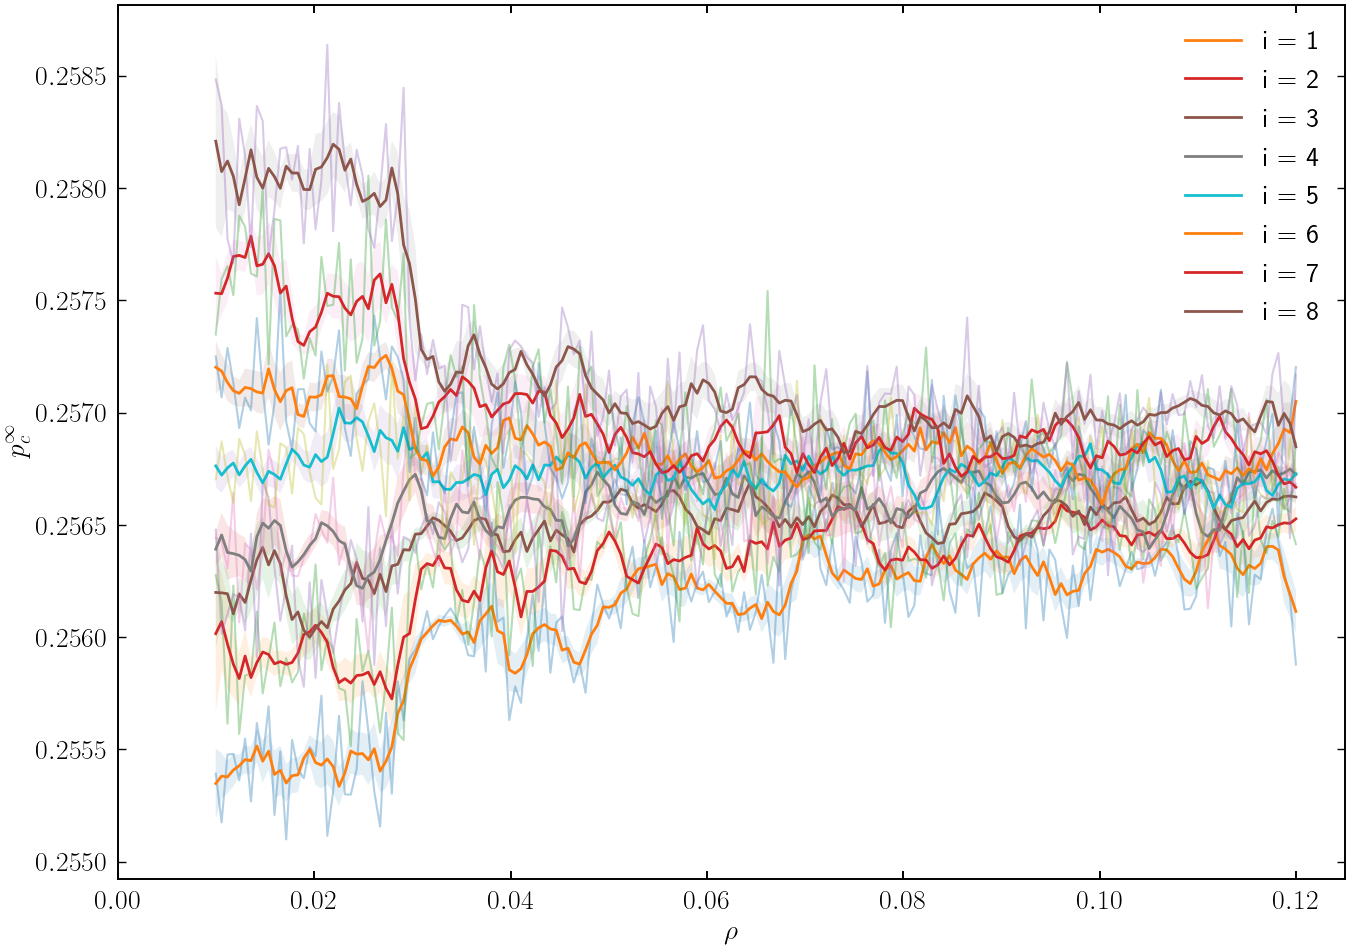

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 512
nc = 8
orders = [i for i in range(1, nc+1)]
P0 = 0.1
p0 = 1.0
WINDOW = 5  # nº de pontos na janela (ajuste conforme quiser)

#plt.figure(figsize=(10,4))

for order in orders:
    df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
    df_f = df_f.sort_values("rho")  # garante ordem crescente no eixo x

    x = df_f["rho"].to_numpy()
    y = df_f["p_mean"].to_numpy()

    # média móvel centrada
    y_ma = (
        pd.Series(y)
        .rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2))
        .mean()
        .to_numpy()
    )

    # desvio padrão na janela e erro padrão da média
    y_std = (
        pd.Series(y)
        .rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2))
        .std()
        .to_numpy()
    )
    y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))  # aproxima

    # série original (mais clarinha) + média móvel
    plt.plot(x, y, alpha=0.35)
    plt.plot(x, y_ma, linewidth=2, label=f"i = {order}")

    # faixa opcional de incerteza (comente se não quiser)
    plt.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)

plt.legend()
plt.xlabel(r"$\rho$")
#plt.axhline(y=0.24881182, xmin=0, xmax=0.5)
plt.ylabel(r"$p_c^{\infty}$")
plt.xlim([0, 1/nc ])
plt.tight_layout()
plt.show()

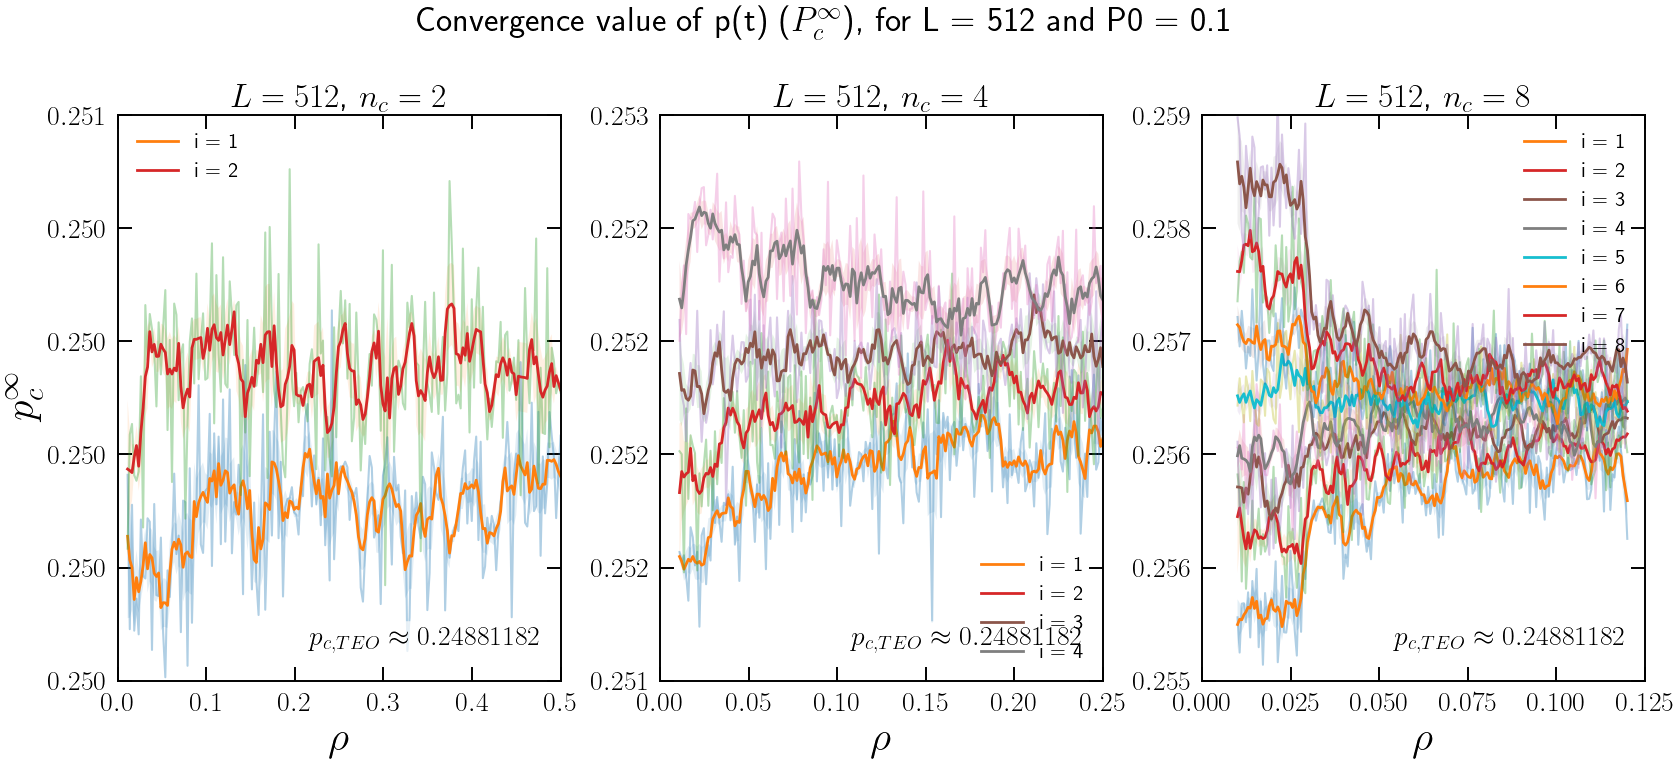

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 512
NC_LIST = [2, 4, 8]
WINDOW = 5
P0 = 0.1
p0 = 1.0
ylims = [(0.2500, 0.2505), (0.2514, 0.2526) ,(0.2550, 0.2585)]

fig, axes = plt.subplots(1, 3, figsize=(17, 8), sharey=False)   # <<-- sem sharey
thickness_axes = 1.4
for ax, nc, ylim in zip(axes, NC_LIST, ylims):
    orders = [i for i in range(1, nc+1)]

    for order in orders:
        df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
        if df_f.empty:
            continue
        df_f = df_f.sort_values("rho")

        x = df_f["rho"].to_numpy()
        y = df_f["p_mean"].to_numpy()

        y_ma = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).mean().to_numpy()
        )
        y_std = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).std().to_numpy()
        )
        y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))

        ax.plot(x, y, alpha=0.35)
        ax.plot(x, y_ma, linewidth=2, label=f"i = {order}")
        ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)

    # limites e ticks específicos por painel
    ax.set_ylim(ylim)
    yticks = np.linspace(ylim[0], ylim[1], 6)           # ajuste o número de ticks se quiser
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"${t:.3f}$" for t in yticks])
    
    ax.set_title(rf"$L = {L}$, $n_c = {nc}$")
    ax.set_xlabel(r"$\rho$",fontsize=30)
    ax.set_xlim([0, 1/nc])
    ax.legend(fontsize=15)
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    ax.text(
        0.95, 0.05,               # (x,y) no sistema [0..1] do eixo
        r"$p_{c,TEO} \approx 0.24881182$",
        transform=ax.transAxes, # usa coords do eixo
        ha="right", va="bottom",
        fontsize=20,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)  # opcional
    )
    #ax.set_ylim(0.250, 0.259)
axes[0].set_ylabel(r"$p_c^{\infty}$",fontsize=30)
fig.suptitle(fr"Convergence value of p(t) ($P_c^\infty$), for L = {L} and P0 = {P0}", fontsize=25, fontweight='bold') # Adds a title to the entire figure
fig.tight_layout()
#plt.savefig(results_folder + "/pc_multi_L_nc.pdf")
plt.show()


/tmp/ipykernel_4212/1740011988.py:94: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.82)


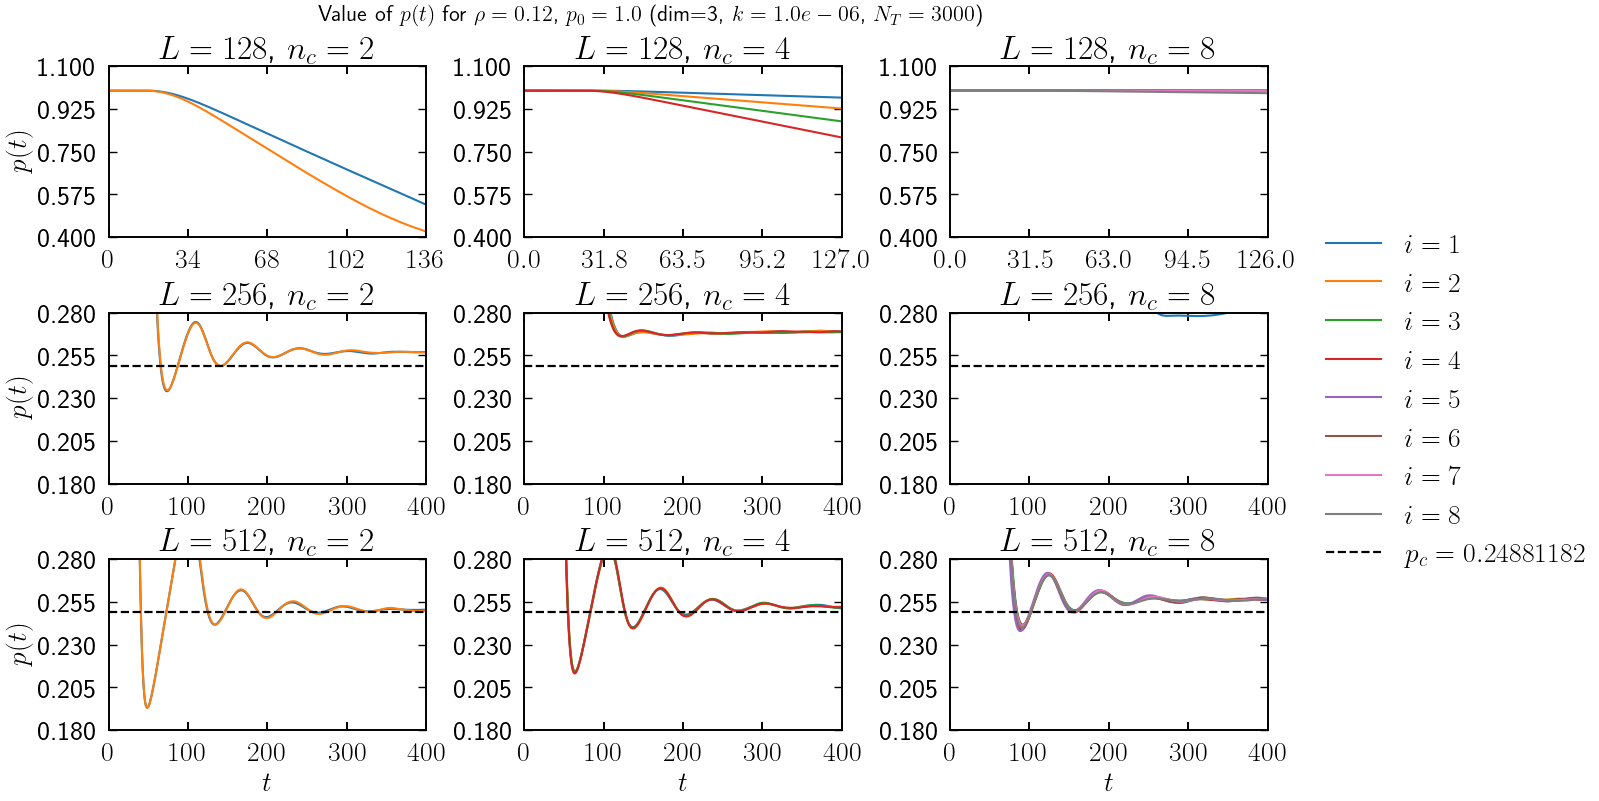

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from matplotlib.ticker import LinearLocator, AutoMinorLocator, FormatStrFormatter

def aplicar_ticks(ax, n_xticks=6, n_yticks=6, yfmt='%.3f'):
    # coloque isto DEPOIS de set_xlim/set_ylim
    ax.xaxis.set_major_locator(LinearLocator(n_xticks))
    ax.yaxis.set_major_locator(LinearLocator(n_yticks))
    
    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    ax.yaxis.set_major_formatter(FormatStrFormatter(yfmt))  # opcional

nc_list = [2, 4, 8]
k=1.0e-06
NT=3000
p0 = 1.0
L_list = [128, 256, 512]
pc_ref = 0.24881182

fig, axes = plt.subplots(3, 3, figsize=(13, 8), sharex=False, sharey=False, constrained_layout=True)

ylims = [(0.2, 1.0), (0.2, 0.4), (0.22, 0.28)]

for i_row, L in enumerate(L_list):            # linhas: L=128,256,512
    for j_col, nc_val in enumerate(nc_list):  # colunas: nc=2,4,8
        ax = axes[i_row, j_col]
        rho = 0.12
        if nc_val != 8:
            rho = 1 / nc_val
        
        filename = (
            f"../Data/bond_percolation/num_colors_{nc_val}/dim_3/"
            f"L_{L}/NT_constant/NT_3000/k_1.0e-06/rho_{rho:.4e}/all_data_bundle.json"
        )

        try:
            bundle, df = read_all_data_bundle(filename, as_dataframe=True)
        except Exception as e:
            ax.text(0.5, 0.5, "arquivo não encontrado\nou erro ao ler",
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
            continue

        if df.empty:
            ax.text(0.5, 0.5, "sem dados", ha='center', va='center',
                    transform=ax.transAxes, fontsize=10)
            ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
            continue

        orders = np.sort(df['order'].unique())
        x_max = 0.0

        for idx_ord, ord_val in enumerate(orders, start=1):
            df_f = df[df['order'] == ord_val]
            if df_f.empty:
                continue
            ax.plot(df_f['t'], df_f['pt'], label=fr'$i={idx_ord}$')
            if len(df_f['t']) and np.nanmax(df_f['t']) > x_max:
                x_max = float(np.nanmax(df_f['t']))

        ax.set_title(fr"$L={L}$, $n_c={nc_val}$")
        if x_max > 0:
            ax.set_xlim(0, int(x_max))
        ax.axhline(y=pc_ref, ls='--', lw=1.6, color='k')  # linha de referência

        if j_col == 0:
            ax.set_ylabel(r'$p(t)$')
        if i_row == len(L_list) - 1:
            ax.set_xlabel(r'$t$')
        ax.set_ylim(0.4, 1.1)
        if i_row != 0:
            ax.set_ylim(0.18, 0.28)
            ax.set_xlim(0, 400)
        
        aplicar_ticks(ax, n_xticks=5, n_yticks=5)
        
# ===== legenda única do lado direito =====
# Cores padrão para mapear i=1..8 consistentemente
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
handles, labels = [], []
for i in range(8):  # i=1..8
    handles.append(Line2D([0], [0], linestyle='-', linewidth=1.5,
                          color=colors[i % len(colors)]))
    labels.append(fr'$i={i+1}$')

# handle para p_c
handles.append(Line2D([0], [0], linestyle='--', linewidth=1.6, color='k'))
labels.append(fr'$p_c={pc_ref}$')

# dá espaço à direita e posiciona a legenda fora
fig.subplots_adjust(right=0.82)
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           frameon=False)

fig.suptitle(fr"Value of $p(t)$ for $\rho={rho}$, $p_0={p0}$ (dim=3, $k={k:.1e}$, $N_T={NT}$)",
             fontsize=16, fontweight='bold')

plt.show()


TypeError: 'AxesSubplot' object is not subscriptable

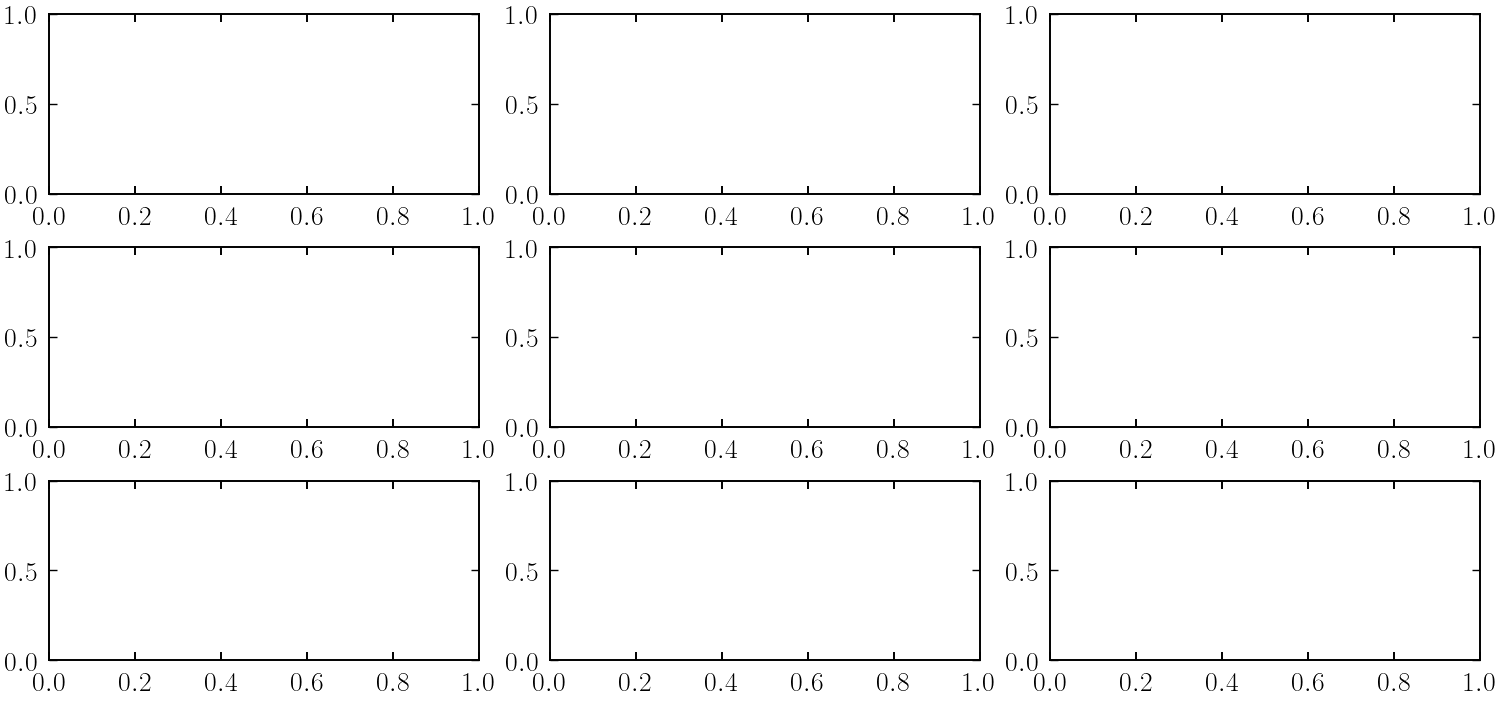

In [ ]:
nc = [2,4,8]
rho = 0.5
p0 = 1.0
L_lst = [128, 256, 512]

fig, axes = plt.subplots(3, 3, figsize=(15, 7), constrained_layout=True)
count = 0
for idx, l in enumerate(L_lst):
    for axs in axes[idx,:]:
        for l in L_lst:
            filename = f"../Data/bond_percolation/num_colors_{nc[idx]}/dim_3/L_{l}/NT_constant/NT_3000/k_1.0e-06/rho_{rho:.4e}/all_data_bundle.json"
            bundle, df = read_all_data_bundle(filename, as_dataframe=True)
            orders = df['order'].unique()
            x_max = 0
            
            for idx, ord in enumerate(orders):
                df_filter = df[df['order']==ord]
                axs[idx, count].plot(df_filter['t'], df_filter['pt'],label=f'$i = {idx+1}$')
            
                if(x_max < max(df_filter['t'])):
                    x_max = max(df_filter['t'])
                
            axs[idx,count].set_title(f"$L = {l}$, $n_c = {nc}$")
            axs[idx,count].set_xlim(0, int(x_max))
            axs[idx,count].axhline(y=0.24881182,xmax=int(x_max),xmin=0, ls='--', lw='1.6', color='k' ,label=r'$p_c = 0.24881182$')
            count += 1


# for ax in axs:
#     ax.set_xlabel('$t$')
#     ax.set_ylim(0.2, 0.3)    
#     ax.legend()
#axs[0].set_ylabel('$p(t)$')
fig.suptitle(fr"Value of $p(t)$, with $N_s = {num_samples}$ samples, for $L = {L}$ and $P0 = {P0}$", fontsize=25, fontweight='bold') # Adds a title to the entire figure
fig.tight_layout()
#plt.savefig(results_folder + f"/pt_series_L_{L}_with_zoom.pdf")
plt.show()

In [138]:
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
3174,512,3000,0.000001,2,0.011030,1.0,0.1,1,50,0.250182,0.000059,2850.780,29.863066,9539302.540,74998.156117
3175,512,3000,0.000001,2,0.011030,1.0,0.1,2,50,0.250117,0.000059,2955.000,24.991884,9540105.360,75031.676194
2872,512,3000,0.000001,2,0.013538,1.0,0.1,1,50,0.250046,0.000060,2803.360,28.682509,9373935.240,81298.242872
2873,512,3000,0.000001,2,0.013538,1.0,0.1,2,50,0.250218,0.000058,2899.700,27.087119,9374516.820,81230.615244
3082,512,3000,0.000001,2,0.016045,1.0,0.1,1,50,0.250156,0.000059,2891.320,27.316773,9633124.940,77766.680260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3363,128,3000,0.000001,2,0.497490,1.0,0.1,2,500,0.368663,0.000480,144.844,0.203219,992574.624,3070.589961
2542,256,3000,0.000001,2,0.500000,1.0,0.1,1,100,0.256731,0.000062,790.800,1.962631,3117258.750,5640.954449
3278,128,3000,0.000001,2,0.500000,1.0,0.1,1,500,0.556922,0.000929,144.390,0.165658,897404.110,2668.764902
2543,256,3000,0.000001,2,0.500000,1.0,0.1,2,100,0.256894,0.000067,798.020,1.846590,3117092.460,5648.742550


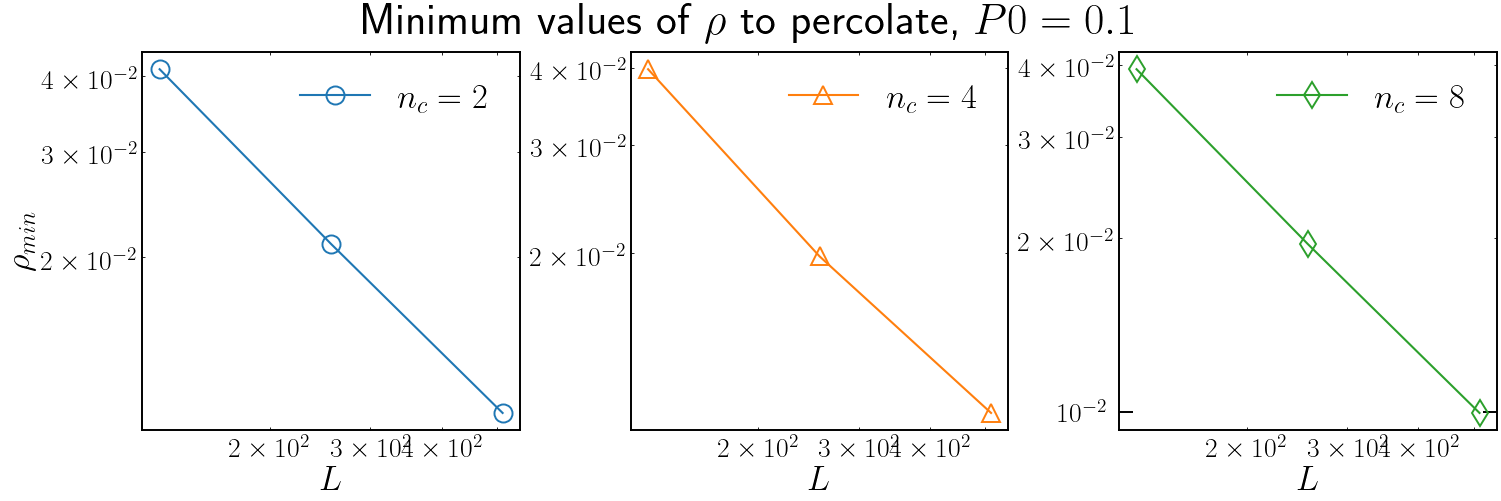

In [40]:
NC_LST = [2, 4, 8]
RHO_LST = [round(1/nc,2) for nc in NC_LST]
p0 = 1.0
P0 = 0.1
L = [128, 256, 512]
order = 1
rho_min_by_nc = {"nc":[], "L":[], "rho_min":[]}

fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
count = 0
for nc in NC_LIST:
    for l in L:
        df_filter = df[(df["L"]==l) & (df["nc"]==nc) & (df['order']==1) & (df["P0"]==P0)]
        rho_min = df_filter['rho'].min()
        
        rho_min_by_nc['nc'].append(nc)
        rho_min_by_nc['L'].append(l)
        rho_min_by_nc['rho_min'].append(rho_min)

df__ = pd.DataFrame(data=rho_min_by_nc)

markers = ["o", "^", "d"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
count =0
ms = 13
fontsize_labels = 25
fontsize_legend = 25
thickness_axes = 1.4

for nc, ax in zip(NC_LST, axs.flatten()):
    df_ = df__[df__["nc"] == nc]
    ax.plot(df_['L'], df_["rho_min"], marker=markers[count],ms = ms, mew=thickness_axes,
            color=colors[count], label=f'$n_c = {nc}$')
    ax.set_xlabel("$L$", fontsize = fontsize_labels)
    ax.legend(fontsize = fontsize_legend)
    count += 1
    
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    ax.set_xscale("log")
    ax.set_yscale("log")
fig.suptitle(fr"Minimum values of $\rho$ to percolate, $P0 = {P0}$", fontsize=32, fontweight='bold') # Adds a title to the entire figure
axs[0].set_ylabel(r'$\rho_{min}$', fontsize = fontsize_labels)
plt.show()
#print(rho_min_by_nc)